# First Look at pm-edge Captured Data

Goals: verify data quality on the local archive, get a feel for the universe, look for obvious patterns or oddities at multiple timescales.

In [1]:
# ruff: noqa: F401, I001

import os
os.environ["PM_EDGE_LOCAL_FORWARD_INDEX_DIR"] = "/Volumes/pm-edge-archive/pm-edge-data/forward_index"
os.environ["PM_EDGE_LOCAL_RESOLVED_DIR"] = "/Volumes/pm-edge-archive/pm-edge-data/resolved_market_outcomes"

from datetime import datetime, timedelta

import pandas as pd

from notebooks.lib.queries import (
    analysis_readiness,
    book_state_quality,
    book_validity,
    capture_freshness,
    data_integrity_checks,
    get_connection,
    hourly_snapshot_volume,
    market_movement,
    metadata_universe,
    multi_timescale_aggregation,
    polymarket_category_expression,
    snapshot_gaps,
    source_breakdown,
    spread_depth_summary,
    trade_overview,
)
from notebooks.lib.plots import (
    plot_book_top_over_time,
    plot_hourly_volume,
    plot_movement_distribution,
    plot_multi_timescale_overlay,
    plot_spread_distribution,
)

con = get_connection()

## Section 1: Capture health overview

In [2]:
df = hourly_snapshot_volume(con)
plot_hourly_volume(df)

In [3]:
source_breakdown(con)

,venue,snapshot_source,count,pct_of_venue
0,kalshi,reconstructed_from_complement,520406,1.00000
1,polymarket,websocket,17313829,0.99857
2,polymarket,rest,24792,0.00143


## Section 2: Data quality verification

In [4]:
book_state_quality(con, venue="polymarket")

,snapshots,avg_bid_levels,avg_ask_levels,pct_with_top_bid,pct_with_top_ask,mean_top_bid,mean_top_ask
0,17338621,3.423388,4.928803,0.808354,0.995555,0.116442,0.098364


In [5]:
book_state_quality(con, venue="kalshi")

,snapshots,avg_bid_levels,avg_ask_levels,pct_with_top_bid,pct_with_top_ask,mean_top_bid,mean_top_ask
0,520406,4.353493,4.537048,0.935769,0.95742,0.470214,0.43568


## Section 3: Integrity, liquidity, and readiness

These checks answer whether the archive is complete enough to analyze. They look for stale capture, missing time buckets, invalid books, shallow liquidity, trade coverage, metadata coverage, duplicate keys, and markets that pass a basic analysis-readiness screen.


In [6]:
capture_freshness(con)


,venue,first_snapshot_utc,latest_snapshot_utc,snapshot_age_minutes,snapshots,distinct_markets,observed_hours,expected_snapshots_at_cadence,pct_expected_snapshots
0,kalshi,2026-05-14 19:47:01.663487-04:00,2026-05-24 13:32:33.914826-04:00,125.366667,520406,560,233.758889,3.141719e+07,0.016564
1,polymarket,2026-05-14 19:47:01.663487-04:00,2026-05-24 13:32:33.914826-04:00,125.366667,17338621,1467,233.758889,8.230183e+07,0.210671


In [7]:
snapshot_gaps(con).head(25)


,venue,bucket,snapshot_count,venue_median,threshold_count
0,kalshi,2026-05-14 22:20:00-04:00,121,300.0,150.0
1,kalshi,2026-05-14 22:25:00-04:00,40,300.0,150.0
2,kalshi,2026-05-14 22:30:00-04:00,40,300.0,150.0
3,kalshi,2026-05-14 22:35:00-04:00,40,300.0,150.0
4,kalshi,2026-05-14 22:40:00-04:00,40,300.0,150.0
5,kalshi,2026-05-14 22:45:00-04:00,40,300.0,150.0
6,kalshi,2026-05-14 22:50:00-04:00,40,300.0,150.0
7,kalshi,2026-05-14 22:55:00-04:00,38,300.0,150.0
8,kalshi,2026-05-14 23:00:00-04:00,40,300.0,150.0
9,kalshi,2026-05-14 23:05:00-04:00,40,300.0,150.0


In [8]:
book_validity(con)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,venue,snapshots,crossed_books,pct_crossed_books,invalid_price_rows,pct_invalid_price_rows,non_positive_spread_rows,pct_non_positive_spread,pct_empty_bid_levels,pct_empty_ask_levels,pct_with_top_both
0,kalshi,520406,0.0,0.0,0.0,0.0,0.0,0.000000,0.064231,0.042580,0.893189
1,polymarket,17338621,0.0,0.0,0.0,0.0,21.0,0.000001,0.191646,0.004445,0.804418


In [9]:
spread_depth_summary(con)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,venue,snapshots,spread_p50,spread_p90,spread_p99,spread_mean,avg_bid_depth,avg_ask_depth,avg_depth_imbalance
0,kalshi,520406,0.010,0.030,0.100,0.019868,2.717384e+04,32348.377249,-6.461652e+03
1,polymarket,17338621,0.002,0.021,0.083,0.009333,2.979458e+06,661681.592686,2.228063e+06


In [10]:
display(trade_overview(con))
metadata_universe(con)


,venue,trades,markets_with_trades,contracts,notional,first_trade_utc,latest_trade_utc,duplicate_trade_ids
0,polymarket,395444,1099,3.097852e+08,4.102094e+07,1779-01-01 12:55:28-05:17:32,2026-05-24 13:32:16.500000-04:00,1


,venue,status,metadata_rows,markets,avg_volume_24h,volume_24h_p50,volume_24h_p90,avg_liquidity,liquidity_p50,avg_hours_to_close
0,kalshi,active,17885,2070,37090.374505,19887.380000,79882.838000,29318.090651,16420.66000,54.714878
1,kalshi,closed,325,223,4421.251046,79.000000,16479.216000,3978.352892,388.00000,-0.427419
2,polymarket,True,212370,2424,297706.864463,156478.948317,559978.137051,605702.835624,30205.13573,3185.777508


In [11]:
data_integrity_checks(con)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,table_name,check_name,issue_count
0,market_metadata_snapshots,null_critical_fields,0.0
1,order_book_snapshots,duplicate_snapshot_keys,0.0
2,order_book_snapshots,null_critical_fields,0.0
3,order_book_snapshots,schema_versions,1.0
4,trade_events,duplicate_trade_ids,53717.0
5,trade_events,null_critical_fields,0.0


In [12]:
readiness = analysis_readiness(
    con,
    min_snapshots=100,
    min_distinct_top_bids=2,
    max_spread_mean=0.10,
)
display(
    readiness.groupby(["venue", "is_analysis_ready", "exclusion_reason"])
    .size()
    .reset_index(name="markets")
    .sort_values(["venue", "is_analysis_ready", "markets"], ascending=[True, False, False])
)
readiness.head(20)


,venue,is_analysis_ready,exclusion_reason,markets
4,kalshi,True,ready,175
2,kalshi,False,no_top_book_movement,296
0,kalshi,False,incomplete_top_book,64
3,kalshi,False,wide_or_missing_spread,16
1,kalshi,False,low_snapshots,9
9,polymarket,True,ready,795
7,polymarket,False,no_top_book_movement,489
5,polymarket,False,incomplete_top_book,163
8,polymarket,False,wide_or_missing_spread,18
6,polymarket,False,low_snapshots,2


,venue,market_id,snapshots,distinct_top_bids,distinct_top_asks,spread_mean,pct_with_top_both,first_snapshot_utc,latest_snapshot_utc,is_analysis_ready,exclusion_reason
0,polymarket,0x0e4a0c937b8934c2475613b6322b3f8edc8dedc24762...,51281,62,62,0.010388,1.000000,2026-05-14 19:47:01.663487-04:00,2026-05-24 13:32:33.914826-04:00,True,ready
1,polymarket,0x518a5b030b205706b8ffe6bbad9bd3de59548348e5c0...,51281,147,159,0.003686,1.000000,2026-05-14 19:47:01.663487-04:00,2026-05-24 13:32:33.914826-04:00,True,ready
2,polymarket,0x789c947a9415600d30d56a4aae88d4111996679b0cae...,51281,20,20,0.001015,1.000000,2026-05-14 19:47:01.663487-04:00,2026-05-24 13:32:33.914826-04:00,True,ready
3,polymarket,0xbcacd5a055f5a9ced6f69f122216c073dd6987d08253...,51280,62,63,0.006054,1.000000,2026-05-14 19:47:01.663487-04:00,2026-05-24 13:32:33.914826-04:00,True,ready
4,polymarket,0x348cd9adf4f6855f58bd9c6dbf9ff251c4142ef77233...,51274,39,39,0.010266,1.000000,2026-05-14 19:47:01.663487-04:00,2026-05-24 13:32:33.914826-04:00,True,ready
5,polymarket,0x4f3421fb2daf5cca7430ed8d8132463963081572d754...,51270,11,13,0.001002,1.000000,2026-05-14 19:47:01.663487-04:00,2026-05-24 13:32:33.914826-04:00,True,ready
6,polymarket,0x9352c559e9648ab4cab236087b64ca85c5b7123a4c7d...,51270,34,39,0.008726,1.000000,2026-05-14 19:47:31.721858-04:00,2026-05-24 13:32:33.914826-04:00,True,ready
7,polymarket,0x0189df05ed7bf84d799213b01a79571e305c03b2ac53...,51268,4,4,0.001000,1.000000,2026-05-14 19:47:16.681893-04:00,2026-05-24 13:32:33.914826-04:00,True,ready
8,polymarket,0xdde06286a7b9464d344f410ab0b3d2ebc6469904e72c...,51268,10,10,0.001029,1.000000,2026-05-14 19:47:16.681893-04:00,2026-05-24 13:32:33.914826-04:00,True,ready
9,polymarket,0x7b52405ad0e0d31bfe970940b67d77f24ecedeab8a23...,51266,2,2,0.001000,1.000000,2026-05-14 19:47:16.681893-04:00,2026-05-24 13:32:33.914826-04:00,True,ready


## Section 4: Market movement

In [13]:
movement = market_movement(con)
plot_movement_distribution(movement)

A market with no movement has repeated snapshots but no observed change in `top_bid` or `top_ask`. That can mean a stable liquid market, a stale market, or a capture path that is not receiving live updates. Inspect source breakdown and book depth before interpreting it as market behavior.

## Section 5: Pick a market and look at it

In [14]:
# Pick the market with the most top-of-book changes
most_active = movement.sort_values("distinct_top_bids", ascending=False).iloc[0]
market_id = most_active["market_id"]
print(
    f"Most active market: {market_id} (venue={most_active['venue']}, snapshots={most_active['snapshots']}, distinct_top_bids={most_active['distinct_top_bids']})"
)

aggs = multi_timescale_aggregation(con, market_id)
plot_multi_timescale_overlay(aggs)

Most active market: 0x7a3c87d49fd8d16969984707f8fe9d927a26f358c9c0dc4c4ab9a5c3b6d7c655 (venue=polymarket, snapshots=14634, distinct_top_bids=466)


## Section 6: Live-watch active Kalshi Eurovision markets

This section watches the most actively-tracked Kalshi Eurovision ranking markets evolve over time. Eurovision 2026 resolves during the broadcast on Saturday evening (May 16). Run this cell repeatedly through the day — after each rsync run, the local archive will have more recent data and the chart will update accordingly.

To refresh the local archive manually before re-running this cell:

```bash
bash ~/ML/pm-edge/deploy/forward_indexer/rsync_to_laptop.sh
```

In [15]:
# Discover all Kalshi Eurovision markets currently in the captured data
eurovision_markets = con.sql("""
    SELECT market_id, COUNT(*) AS snapshots, MIN(timestamp_utc) AS first_seen
    FROM order_book_snapshots
    WHERE venue = 'kalshi' AND market_id LIKE 'KXEUROVISIONRANK%'
    GROUP BY market_id
    ORDER BY snapshots DESC
""").fetchdf()
eurovision_markets

,market_id,snapshots,first_seen
0,KXEUROVISIONRANK-26TOP10-MOL,5408,2026-05-15 19:40:49.129912-04:00
1,KXEUROVISIONRANK-26TOP10-AUS,5276,2026-05-15 19:40:49.129912-04:00
2,KXEUROVISIONRANK-26TOP10-ITA,4761,2026-05-15 19:40:49.129912-04:00
3,KXEUROVISIONRANK-26TOP5-AUS,4379,2026-05-15 19:40:49.129912-04:00
4,KXEUROVISIONRANK-26TOP5-ITA,3104,2026-05-15 19:40:49.129912-04:00
5,KXEUROVISIONRANK-26TOP10-BUL,1174,2026-05-16 13:54:19.968984-04:00
6,KXEUROVISIONRANK-26TOP10-ALB,915,2026-05-16 13:54:19.968984-04:00
7,KXEUROVISIONRANK-26TOP3-FRA,826,2026-05-16 15:34:34.721376-04:00
8,KXEUROVISIONRANK-26TOP3-MOL,760,2026-05-16 13:54:19.968984-04:00
9,KXEUROVISIONRANK-26TOP10-ISR,664,2026-05-16 15:34:34.721376-04:00


In [16]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

if len(eurovision_markets) == 0:
    print("No Kalshi Eurovision markets found in the captured data. Nothing to plot.")
else:
    market_ids = eurovision_markets["market_id"].tolist()

    fig = make_subplots(
        rows=len(market_ids),
        cols=1,
        subplot_titles=market_ids,
        shared_xaxes=True,
        vertical_spacing=0.02,
    )

    for i, market_id in enumerate(market_ids, start=1):
        df = con.sql(f"""
            SELECT date_trunc('minute', timestamp_utc) AS minute,
                   AVG(top_bid) AS top_bid,
                   AVG(top_ask) AS top_ask
            FROM order_book_snapshots
            WHERE venue = 'kalshi' AND market_id = '{market_id}'
            GROUP BY minute
            ORDER BY minute
        """).fetchdf()

        fig.add_trace(
            go.Scatter(
                x=df["minute"],
                y=df["top_bid"],
                name="top_bid",
                line={"color": "blue"},
                showlegend=(i == 1),
            ),
            row=i,
            col=1,
        )
        fig.add_trace(
            go.Scatter(
                x=df["minute"],
                y=df["top_ask"],
                name="top_ask",
                line={"color": "red"},
                showlegend=(i == 1),
            ),
            row=i,
            col=1,
        )

    fig.update_layout(
        height=200 * len(market_ids),
        title="Eurovision rank markets — top_bid (blue) and top_ask (red) over time",
        margin={"t": 50, "b": 30, "l": 50, "r": 30},
    )
    fig.show()

## Section 6: Depth-dependent trade investigation

This section investigates trades whose size exceeds the contemporaneous level-1 opposing-side book size. The goal is to identify which markets, categories, and trade-size ranges drive the current depth-walking requirement for simulator v1.


### 6.1 What fraction of trades require depth, by venue and market?

Build a fresh-trade classification table using the latest prior book snapshot within 60 seconds, then rank markets by the fraction of trades larger than level-1 opposing-side size.


In [17]:
con.sql("""
    CREATE OR REPLACE TEMP TABLE depth_trade_classified AS
    WITH trades_with_book AS (
        SELECT
            t.venue,
            t.market_id,
            t.timestamp_utc,
            t.price,
            t.size AS trade_size,
            lower(t.side) AS side,
            b.bid_levels,
            b.ask_levels,
            EXTRACT(EPOCH FROM (t.timestamp_utc - b.timestamp_utc)) AS lag_seconds
        FROM trade_events t
        ASOF LEFT JOIN order_book_snapshots b
            ON t.market_id = b.market_id
            AND t.venue = b.venue
            AND t.timestamp_utc >= b.timestamp_utc
    )
    SELECT
        venue,
        market_id,
        timestamp_utc,
        price,
        trade_size,
        side,
        lag_seconds,
        CASE
            WHEN side = 'buy' AND len(ask_levels) > 0 THEN ask_levels[1].size
            WHEN side = 'sell' AND len(bid_levels) > 0 THEN bid_levels[1].size
            ELSE NULL
        END AS level_1_size,
        CASE
            WHEN side = 'buy' AND len(ask_levels) > 0 AND trade_size > ask_levels[1].size THEN 1
            WHEN side = 'sell' AND len(bid_levels) > 0 AND trade_size > bid_levels[1].size THEN 1
            ELSE 0
        END AS depth_required
    FROM trades_with_book
    WHERE lag_seconds <= 60
""")

depth_overall = con.sql("""
    SELECT
        venue,
        COUNT(*) AS total_trades,
        SUM(depth_required) AS depth_trades,
        SUM(depth_required)::DOUBLE / COUNT(*) AS depth_rate
    FROM depth_trade_classified
    WHERE level_1_size IS NOT NULL
    GROUP BY venue
    ORDER BY venue
""").fetchdf()

con.sql("""
    CREATE OR REPLACE TEMP TABLE depth_trades_view AS
    SELECT
        venue,
        market_id,
        COUNT(*) AS total_trades,
        SUM(depth_required) AS depth_trades,
        SUM(depth_required)::DOUBLE / COUNT(*) AS depth_rate,
        AVG(trade_size) AS avg_trade_size,
        AVG(level_1_size) AS avg_level_1_size
    FROM depth_trade_classified
    WHERE level_1_size IS NOT NULL
    GROUP BY venue, market_id
    HAVING COUNT(*) >= 20
""")

depth_trades = con.sql("""
    SELECT *
    FROM depth_trades_view
    ORDER BY depth_rate DESC, total_trades DESC
""").fetchdf()

display(depth_overall)
display(depth_trades.head(20))


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,venue,total_trades,depth_trades,depth_rate
0,polymarket,350972,35660.0,0.101604


,venue,market_id,total_trades,depth_trades,depth_rate,avg_trade_size,avg_level_1_size
0,polymarket,0x8bb861046d70534248fe10aaef5ca28a91fe4c923db0...,184,112.0,0.608696,276.417105,170.390435
1,polymarket,0x707ab64115b0ca83b65bc5137aaa947a11f56885ed82...,152,88.0,0.578947,205.013616,138.328750
2,polymarket,0xc9615bb82d6535d630ff98e8094060bc767d8b944651...,595,344.0,0.578151,101.014926,162.980471
3,polymarket,0x84dc47b1dd9cd99a9217b92a95690729334b647650bb...,56,29.0,0.517857,431.993860,237.651607
4,polymarket,0x60ecb823bb667a51ccf9ffcb1cab2c48899cd1641068...,66,34.0,0.515152,92.368501,192.048939
5,polymarket,0xb9e518a563d955037698fec22b03bca649aeb4423fc0...,20,10.0,0.500000,1438.648952,998.908000
6,polymarket,0xaa5cdb6830cbfa2ca711b7cf93bd42cf4f8e062d44ea...,650,316.0,0.486154,5365.322867,2292.951092
7,polymarket,0x83831604f88a889311dc484abc0d327d96f494bba9d4...,89,43.0,0.483146,414.063910,190.551236
8,polymarket,0xbeab83146920be8f52b52fdbcb3464b24dc553f7b47e...,1607,771.0,0.479776,237.555415,239.324381
9,polymarket,0x988705fdff46d99a14e7e6ae7200e49514c76459064b...,49,23.0,0.469388,302.452535,554.994490


### 6.2 What does the depth-dependence rate look like as a distribution?

This histogram shows whether depth-dependence is concentrated in a small long tail of markets or spread broadly across the actively traded universe. The dashed reference line marks the full-archive v0 assumption-suite depth dependency rate of `10.32%`.


In [18]:
import plotly.express as px

if len(depth_trades) == 0:
    print("No markets met the minimum trade-count threshold for depth distribution.")
else:
    fig = px.histogram(
        depth_trades,
        x="depth_rate",
        color="venue",
        nbins=40,
        barmode="overlay",
        opacity=0.70,
        title="Distribution of depth-dependence rate by market",
        labels={"depth_rate": "Depth-dependent trade rate", "count": "Markets"},
    )
    fig.add_vline(
        x=0.1032,
        line_dash="dash",
        line_color="black",
        annotation_text="archive avg 10.32%",
    )
    fig.show()


### 6.3 How does depth-dependence correlate with trade size?

Bucket fresh trades by size and compute the depth-dependence rate in each bucket. This identifies where level-1-only simulation starts to understate fills materially.


In [19]:
size_buckets = con.sql("""
    SELECT
        venue,
        CASE
            WHEN trade_size < 10 THEN '00_under_10'
            WHEN trade_size < 100 THEN '01_10_to_100'
            WHEN trade_size < 1000 THEN '02_100_to_1000'
            WHEN trade_size < 10000 THEN '03_1000_to_10000'
            ELSE '04_over_10000'
        END AS size_bucket,
        COUNT(*) AS trades,
        SUM(depth_required) AS depth_trades,
        SUM(depth_required)::DOUBLE / COUNT(*) AS depth_rate
    FROM depth_trade_classified
    WHERE level_1_size IS NOT NULL
    GROUP BY venue, size_bucket
    ORDER BY venue, size_bucket
""").fetchdf()

display(size_buckets)

if len(size_buckets) == 0:
    print("No fresh trades with level-1 size available for size-bucket analysis.")
else:
    fig = px.bar(
        size_buckets,
        x="size_bucket",
        y="depth_rate",
        color="venue",
        barmode="group",
        text="trades",
        title="Depth-dependence rate by trade-size bucket",
        labels={
            "size_bucket": "Trade-size bucket",
            "depth_rate": "Depth-dependent trade rate",
            "trades": "Trades",
        },
    )
    fig.update_layout(xaxis_tickangle=-30)
    fig.show()


,venue,size_bucket,trades,depth_trades,depth_rate
0,polymarket,00_under_10,86584,1087.0,0.012554
1,polymarket,01_10_to_100,129907,12861.0,0.099002
2,polymarket,02_100_to_1000,103690,14586.0,0.140669
3,polymarket,03_1000_to_10000,26986,6032.0,0.223523
4,polymarket,04_over_10000,3805,1094.0,0.287516


### 6.4 Can we identify the market categories where depth-dependence concentrates?

Polymarket market metadata does not expose a top-level category column, but `raw_json` includes structured Gamma fields. This section inspects those fields, then groups Polymarket by normalized `feeType` values such as `sports`, `politics`, `crypto`, `culture`, and `finance`. Kalshi tickers still use prefix parsing when trade data exists.


In [20]:
# Inspect available metadata fields and structured Polymarket category candidates
metadata_sample = con.sql("""
    SELECT
        venue,
        market_id,
        captured_at_utc,
        json_extract_string(raw_json, '$.feeType') AS fee_type,
        json_extract_string(raw_json, '$.question') AS question,
        json_extract_string(raw_json, '$.slug') AS slug,
        json_extract_string(raw_json, '$.groupItemTitle') AS group_item_title
    FROM market_metadata_snapshots
    WHERE venue = 'polymarket'
    LIMIT 5
""").fetchdf()

metadata_fee_types = con.sql("""
    SELECT
        json_extract_string(raw_json, '$.feeType') AS fee_type,
        COUNT(*) AS metadata_rows,
        COUNT(DISTINCT market_id) AS markets
    FROM market_metadata_snapshots
    WHERE venue = 'polymarket'
    GROUP BY fee_type
    ORDER BY markets DESC
""").fetchdf()

display(metadata_sample)
display(metadata_fee_types)


,venue,market_id,captured_at_utc,fee_type,question,slug,group_item_title
0,polymarket,0x0622b01925e56a091f248c42fb194d3b86d58165f664...,2026-05-14 19:45:50.155493-04:00,politics_fees,Will Mauricio Cardenas win the 2026 Colombian ...,will-mauricio-cardenas-win-the-2026-colombian-...,Mauricio Cárdenas
1,polymarket,0xa8599f4c633fb98f7543e04b20f91052564a6fbe8e02...,2026-05-14 19:45:50.155493-04:00,culture_fees,Will Richard Van De Water win The Bachelorette...,will-richard-van-de-water-win-the-bachelorette...,Richard Van De Water
2,polymarket,0x6a5589de888a72e9e1d711a323ceb1794c9135d4f4a2...,2026-05-14 19:45:50.155493-04:00,politics_fees,Will Al Mina be the Republican nominee for Sen...,will-al-mina-be-the-republican-nominee-for-sen...,Al Mina
3,polymarket,0x70f1a7d2cd490b640676d5e31470bcbe16fef40087de...,2026-05-14 19:45:50.155493-04:00,politics_fees,Will Eduardo Leite win the 2026 Brazilian pres...,will-eduardo-leite-win-the-2026-brazilian-pres...,Eduardo Leite
4,polymarket,0x1c842b91d226266fbe0e55d9bce9c52ce48b825d069e...,2026-05-14 19:45:50.155493-04:00,crypto_fees_v2,Metamask FDV above $700M one day after launch?,metamask-fdv-above-700m-one-day-after-launch-6...,$700M


,fee_type,metadata_rows,markets
0,sports_fees_v2,69781,989
1,NaN,30346,651
2,politics_fees,51158,422
3,crypto_fees_v2,16982,229
4,culture_fees,14850,199
5,finance_prices_fees,13317,141
6,tech_fees,8363,92
7,economics_fees,6126,47
8,weather_fees,1000,11
9,general_fees,444,5


In [21]:
polymarket_category_sql = polymarket_category_expression("m.raw_json")
categorized = con.sql(f"""
    WITH latest_metadata AS (
        SELECT
            venue,
            market_id,
            raw_json,
            json_extract_string(raw_json, '$.feeType') AS fee_type,
            json_extract_string(raw_json, '$.question') AS question,
            json_extract_string(raw_json, '$.slug') AS slug,
            ROW_NUMBER() OVER (
                PARTITION BY venue, market_id
                ORDER BY captured_at_utc DESC
            ) AS rn
        FROM market_metadata_snapshots
    ),
    market_depth_with_category AS (
        SELECT
            d.venue,
            d.market_id,
            d.total_trades,
            d.depth_trades,
            d.depth_rate,
            CASE
                WHEN d.venue = 'kalshi' THEN regexp_extract(d.market_id, '^(KX[A-Z]+)', 1)
                WHEN d.venue = 'polymarket' THEN {polymarket_category_sql}
                ELSE 'uncategorized'
            END AS category,
            m.fee_type,
            m.question,
            m.slug
        FROM depth_trades_view d
        LEFT JOIN latest_metadata m
            ON d.venue = m.venue
            AND d.market_id = m.market_id
            AND m.rn = 1
    )
    SELECT
        venue,
        category,
        COUNT(*) AS markets,
        SUM(total_trades) AS total_trades,
        SUM(depth_trades) AS depth_trades,
        SUM(depth_trades)::DOUBLE / SUM(total_trades) AS weighted_depth_rate,
        AVG(depth_rate) AS avg_market_depth_rate
    FROM market_depth_with_category
    GROUP BY venue, category
    HAVING SUM(total_trades) >= 100
    ORDER BY weighted_depth_rate DESC, total_trades DESC
""").fetchdf()

categorized


,venue,category,markets,total_trades,depth_trades,weighted_depth_rate,avg_market_depth_rate
0,polymarket,culture,62,20416.0,4202.0,0.205819,0.165546
1,polymarket,tech,2,493.0,96.0,0.194726,0.320705
2,polymarket,geopolitics,74,83182.0,15563.0,0.187096,0.231781
3,polymarket,polymarket_uncategorized,55,46849.0,6562.0,0.140067,0.128082
4,polymarket,politics,47,10209.0,1423.0,0.139387,0.084318
5,polymarket,crypto,14,5112.0,536.0,0.104851,0.145084
6,polymarket,finance,13,13774.0,1178.0,0.085523,0.114637
7,polymarket,sports,145,156033.0,5709.0,0.036588,0.071732
8,polymarket,economics,8,10723.0,154.0,0.014362,0.025122
9,polymarket,weather,1,2372.0,18.0,0.007589,0.007589


### Section 6 findings

_Fill this in after running the queries above._

Key observations:
- Overall depth-dependence rate: __%
- Top markets driving depth-dependence: __, __, __
- Distribution shape: [long tail / broad] — _Section 6.2_
- Size threshold for depth-walking importance: trades larger than __ contracts — _Section 6.3_
- Most affected categories: `polymarket_uncategorized`, `culture`, `politics`, `finance`, `sports` by weighted depth rate — _Section 6.4_

V1 simulator implication: [depth walking is essential for category X / depth walking is a long-tail edge case / etc.]


## Section 7: Uncategorized Polymarket markets — what are they?

Section 6.4 showed `polymarket_uncategorized` at 19.50% depth-dependence, higher than any classified category. This section investigates whether those markets share a coherent identity (e.g., a genuine market type we missed) or are a heterogeneous bucket (e.g., metadata-incomplete warm-up artifacts, retired markets, edge cases).

The answer determines whether the categorization logic should be extended or whether the uncategorized bucket is genuinely residual.


In [22]:
uncategorized_sample = con.sql("""
    WITH latest_metadata AS (
        SELECT
            venue,
            market_id,
            raw_json,
            captured_at_utc,
            ROW_NUMBER() OVER (
                PARTITION BY venue, market_id
                ORDER BY captured_at_utc DESC
            ) AS rn
        FROM market_metadata_snapshots
        WHERE venue = 'polymarket'
    )
    SELECT market_id, captured_at_utc, raw_json
    FROM latest_metadata
    WHERE rn = 1
      AND (
          json_extract_string(raw_json, '$.feeType') IS NULL
          OR json_extract_string(raw_json, '$.feeType') = ''
      )
    ORDER BY captured_at_utc DESC
    LIMIT 20
""").fetchdf()
uncategorized_sample


,market_id,captured_at_utc,raw_json
0,0xbf1d0865f793f94d78413696946f89327bda5ae44d82...,2026-05-24 12:48:23.921649-04:00,"{""acceptingOrders"": true, ""acceptingOrdersTime..."
1,0x43272c02b8407ed3f8d5b04fb4cb132d7a59c5df6ecc...,2026-05-24 12:48:23.921649-04:00,"{""acceptingOrders"": true, ""acceptingOrdersTime..."
2,0xa1b6ebba4e86fe9bfb2c206dba71be111d2e1047d7b7...,2026-05-24 12:48:23.921649-04:00,"{""acceptingOrders"": true, ""acceptingOrdersTime..."
3,0xf1393f9076b29364f7db272a17882cc9a00792d440ec...,2026-05-24 12:48:23.921649-04:00,"{""accepting_order_timestamp"": ""2026-05-22T04:0..."
4,0x10be5bb8b2f115699c67f0189cdb6db051f2a5fb4ec2...,2026-05-24 12:48:23.921649-04:00,"{""acceptingOrders"": true, ""acceptingOrdersTime..."
5,0xbcacd5a055f5a9ced6f69f122216c073dd6987d08253...,2026-05-24 12:48:23.921649-04:00,"{""acceptingOrders"": true, ""acceptingOrdersTime..."
6,0x9772347ce628f4427ab437333679512aba5a98a4d14f...,2026-05-24 12:48:23.921649-04:00,"{""acceptingOrders"": true, ""acceptingOrdersTime..."
7,0x674c0894f8992fd36943cc88b4cbcc90cbd8fac9ae3b...,2026-05-24 12:48:23.921649-04:00,"{""acceptingOrders"": true, ""acceptingOrdersTime..."
8,0x1827f7e35c24f0cd5ff86318af815e61fdf89364977e...,2026-05-24 12:48:23.921649-04:00,"{""acceptingOrders"": true, ""acceptingOrdersTime..."
9,0xbdc79410f7282a6606b09616c87504d7c268ec76f990...,2026-05-24 12:48:23.921649-04:00,"{""acceptingOrders"": true, ""acceptingOrdersTime..."


In [23]:
import json

uncategorized_fields = {}
for _, row in uncategorized_sample.iterrows():
    try:
        parsed = json.loads(row["raw_json"])
        for key in parsed:
            uncategorized_fields[key] = uncategorized_fields.get(key, 0) + 1
    except (json.JSONDecodeError, TypeError):
        continue

field_freq = pd.DataFrame(
    [
        {"field": k, "count": v, "pct": v / len(uncategorized_sample) * 100}
        for k, v in uncategorized_fields.items()
    ]
).sort_values("count", ascending=False)
field_freq.head(30)


,field,count,pct
10,closed,20,100.0
2,active,20,100.0
4,archived,20,100.0
18,description,20,100.0
32,image,20,100.0
52,question,20,100.0
30,icon,20,100.0
50,pagerDutyNotificationEnabled,19,95.0
55,requiresTranslation,19,95.0
54,ready,19,95.0


In [24]:
samples = []
for _, row in uncategorized_sample.head(10).iterrows():
    try:
        parsed = json.loads(row["raw_json"])
        sample = {
            "market_id_short": row["market_id"][:20] + "...",
            "captured_at": row["captured_at_utc"],
        }
        for field in [
            "question",
            "title",
            "name",
            "description",
            "eventTitle",
            "event_title",
            "outcome",
        ]:
            if field in parsed:
                sample[field] = str(parsed[field])[:150]
                break
        samples.append(sample)
    except (json.JSONDecodeError, TypeError):
        continue

pd.DataFrame(samples)


,market_id_short,captured_at,question
0,0xbf1d0865f793f94d78...,2026-05-24 12:48:23.921649-04:00,Israel closes its airspace by May 31?
1,0x43272c02b8407ed3f8...,2026-05-24 12:48:23.921649-04:00,Will Reza Pahlavi enter Iran by June 30?
2,0xa1b6ebba4e86fe9bfb...,2026-05-24 12:48:23.921649-04:00,Will Alireza Arafi be head of state in Iran en...
3,0xf1393f9076b29364f7...,2026-05-24 12:48:23.921649-04:00,Roland Garros ATP: Alejandro Davidovich Fokina...
4,0x10be5bb8b2f115699c...,2026-05-24 12:48:23.921649-04:00,Will Russia enter Dopropillia by June 30?
5,0xbcacd5a055f5a9ced6...,2026-05-24 12:48:23.921649-04:00,US obtains Iranian enriched uranium by May 31?
6,0x9772347ce628f4427a...,2026-05-24 12:48:23.921649-04:00,Ukraine agrees not to join NATO by June 30?
7,0x674c0894f8992fd369...,2026-05-24 12:48:23.921649-04:00,Will Zelenskyy and Putin meet next in Switzerl...
8,0x1827f7e35c24f0cd5f...,2026-05-24 12:48:23.921649-04:00,Will Trump and Putin meet next in Japan?
9,0xbdc79410f7282a6606...,2026-05-24 12:48:23.921649-04:00,Another Canada election called by June 30?


In [25]:
uncategorized_depth_check = con.sql("""
    WITH latest_metadata AS (
        SELECT
            venue,
            market_id,
            raw_json,
            ROW_NUMBER() OVER (
                PARTITION BY venue, market_id
                ORDER BY captured_at_utc DESC
            ) AS rn
        FROM market_metadata_snapshots
        WHERE venue = 'polymarket'
    ),
    classified AS (
        SELECT
            d.market_id,
            d.total_trades,
            d.depth_rate,
            d.avg_trade_size,
            d.avg_level_1_size,
            CASE
                WHEN m.raw_json IS NULL THEN 'no_metadata_row'
                WHEN json_extract_string(m.raw_json, '$.feeType') IS NULL THEN 'no_feeType'
                WHEN json_extract_string(m.raw_json, '$.feeType') = '' THEN 'empty_feeType'
                ELSE 'has_feeType'
            END AS classification_status
        FROM depth_trades_view d
        LEFT JOIN latest_metadata m
            ON d.venue = m.venue
            AND d.market_id = m.market_id
            AND m.rn = 1
        WHERE d.venue = 'polymarket'
    )
    SELECT
        classification_status,
        COUNT(*) AS markets,
        SUM(total_trades) AS total_trades,
        AVG(depth_rate) AS avg_depth_rate,
        AVG(avg_trade_size) AS avg_trade_size,
        AVG(avg_level_1_size) AS avg_level_1_size
    FROM classified
    GROUP BY classification_status
    ORDER BY markets DESC
""").fetchdf()
uncategorized_depth_check


,classification_status,markets,total_trades,avg_depth_rate,avg_trade_size,avg_level_1_size
0,has_feeType,293,219157.0,0.098974,1303.273882,2.099576e+06
1,no_feeType,129,130031.0,0.187568,558.978059,3.114156e+04


### Section 7 findings

Run the queries above and fill in:

- **Uncategorized bucket composition:**
  - no_metadata_row: ___ markets (indexer coverage gap)
  - no_feeType: ___ markets (different market type)
  - empty_feeType: ___ markets (awaiting classification)

- **Coherence assessment:** [coherent — all share characteristic X / scattered — no clear pattern]
- **Recommended action:**
  - If coherent: extend categorization logic to capture them under a new label
  - If scattered: leave as residual, focus depth-walking work on identified high-depth categories instead
  - If indexer coverage gap: file TODO for indexer metadata capture improvement

- **Updated v1 priorities:** [depth-walking for culture markets remains priority / new category X needs attention / no change]


## Section 8: Category-segmented calibration analysis

Entry 19 showed that the first lag-clean calibration subset is dominated by Kalshi MLB markets. This section segments the same lag-clean resolution set by market category to check whether aggregate calibration hides category-specific behavior. Polymarket categories use `polymarket_category_expression`; Kalshi categories use ticker-prefix rules.


In [26]:
from pathlib import Path

resolved_dir = Path(
    os.environ.get(
        "PM_EDGE_LOCAL_RESOLVED_DIR",
        str(Path(os.environ["PM_EDGE_LOCAL_FORWARD_INDEX_DIR"]).parent / "resolved_market_outcomes"),
    )
)
resolved_glob = str(resolved_dir / "**" / "*.parquet")
polymarket_category_sql = polymarket_category_expression("m.raw_json")

calibration_clean = con.sql(f"""
    WITH resolutions AS (
        SELECT
            venue,
            market_id,
            resolved_value,
            final_top_bid,
            final_top_ask,
            (final_top_bid + final_top_ask) / 2.0 AS implied_prob,
            EXTRACT(EPOCH FROM (venue_resolved_at_utc - final_snapshot_timestamp_utc)) / 60 AS lag_minutes
        FROM read_parquet('{resolved_glob}', union_by_name=true)
        WHERE final_top_bid IS NOT NULL
          AND final_top_ask IS NOT NULL
          AND resolved_value IN (0.0, 1.0)
          AND venue_resolved_at_utc IS NOT NULL
    ),
    latest_metadata AS (
        SELECT
            venue,
            market_id,
            raw_json,
            ROW_NUMBER() OVER (
                PARTITION BY venue, market_id
                ORDER BY captured_at_utc DESC
            ) AS rn
        FROM market_metadata_snapshots
    )
    SELECT
        r.*,
        CASE
            WHEN r.venue = 'polymarket' THEN {polymarket_category_sql}
            ELSE NULL
        END AS polymarket_category
    FROM resolutions r
    LEFT JOIN latest_metadata m
      ON r.venue = m.venue
     AND r.market_id = m.market_id
     AND m.rn = 1
    WHERE r.lag_minutes > 0
      AND r.lag_minutes < 240
""").df()


def categorize_kalshi(market_id: str) -> str:
    if market_id.startswith("KXEUROVISIONRANK"):
        return "eurovision"
    if market_id.startswith("KXMLB"):
        return "mlb"
    if market_id.startswith("KXNBA") or market_id.startswith("KXNFL"):
        return "other_sports"
    if market_id.startswith("KXMVE"):
        return "multivariate_esports"
    if market_id.startswith("KXXRP") or market_id.startswith("KXBTC"):
        return "crypto_threshold"
    return "kalshi_other"


calibration_clean["category"] = calibration_clean.apply(
    lambda row: categorize_kalshi(row["market_id"])
    if row["venue"] == "kalshi"
    else row["polymarket_category"],
    axis=1,
)

print(f"Lag-clean calibration rows: {len(calibration_clean)}")
calibration_clean.head()


Lag-clean calibration rows: 230


,venue,market_id,resolved_value,final_top_bid,final_top_ask,implied_prob,lag_minutes,polymarket_category,category
0,kalshi,KXBTCD-26MAY1617-T78499.99,0.0,0.17,0.18,0.175,91.808561,NaN,crypto_threshold
1,kalshi,KXMLBSPREAD-26MAY161910MILMIN-MIL2,0.0,0.41,0.42,0.415,203.522195,NaN,mlb
2,kalshi,KXMLBKS-26MAY161415KCSTL-STLKLEAHY62-4,0.0,0.54,0.55,0.545,113.208561,NaN,mlb
3,kalshi,KXMLBSPREAD-26MAY161605PHIPIT-PHI6,1.0,0.75,0.77,0.760,0.314750,NaN,mlb
4,kalshi,KXAAAGASD-26MAY17-4.500,1.0,0.97,0.98,0.975,107.283644,NaN,kalshi_other


In [27]:
category_summary = calibration_clean.groupby("category").agg(
    n=("resolved_value", "size"),
    realized_yes_rate=("resolved_value", "mean"),
    mean_implied=("implied_prob", "mean"),
)
category_summary["gap"] = category_summary["realized_yes_rate"] - category_summary["mean_implied"]
category_summary["brier"] = calibration_clean.groupby("category").apply(
    lambda x: ((x["implied_prob"] - x["resolved_value"]) ** 2).mean(),
    include_groups=False,
)
category_summary.sort_values("n", ascending=False)


,n,realized_yes_rate,mean_implied,gap,brier
category,,,,,
mlb,167,0.365269,0.388832,-0.023563,0.159474
crypto_threshold,42,0.761905,0.507381,0.254524,0.221202
kalshi_other,11,0.363636,0.411364,-0.047727,0.095743
eurovision,7,0.714286,0.585000,0.129286,0.085046
sports,2,0.000000,0.360000,-0.360000,0.147825
culture,1,0.000000,0.002500,-0.002500,0.000006


In [28]:
for category in sorted(calibration_clean["category"].dropna().unique()):
    subset = calibration_clean[calibration_clean["category"] == category].copy()
    if len(subset) < 5:
        continue
    print(f"\n{'=' * 60}")
    print(f"Category: {category}  (n={len(subset)})")
    print(
        f"Overall: implied {subset['implied_prob'].mean():.3f} "
        f"-> realized {subset['resolved_value'].mean():.3f}"
    )
    subset["bin"] = pd.cut(
        subset["implied_prob"],
        bins=[0, 0.25, 0.5, 0.75, 1.0],
        include_lowest=True,
    )
    print(
        subset.groupby("bin", observed=True)
        .agg(
            n=("resolved_value", "size"),
            realized=("resolved_value", "mean"),
            avg_implied=("implied_prob", "mean"),
        )
        .to_string()
    )
    brier = ((subset["implied_prob"] - subset["resolved_value"]) ** 2).mean()
    print(f"Brier: {brier:.4f}")



Category: crypto_threshold  (n=42)
Overall: implied 0.507 -> realized 0.762
                 n  realized  avg_implied
bin                                      
(-0.001, 0.25]  16       0.5     0.067500
(0.25, 0.5]      5       0.6     0.389000
(0.5, 0.75]      4       1.0     0.632500
(0.75, 1.0]     17       1.0     0.926765
Brier: 0.2212

Category: eurovision  (n=7)
Overall: implied 0.585 -> realized 0.714
                n  realized  avg_implied
bin                                     
(-0.001, 0.25]  1       0.0       0.0450
(0.25, 0.5]     1       0.0       0.3400
(0.5, 0.75]     3       1.0       0.6050
(0.75, 1.0]     2       1.0       0.9475
Brier: 0.0850

Category: kalshi_other  (n=11)
Overall: implied 0.411 -> realized 0.364
                n  realized  avg_implied
bin                                     
(-0.001, 0.25]  5       0.0     0.078000
(0.25, 0.5]     2       0.5     0.327500
(0.5, 0.75]     1       0.0     0.695000
(0.75, 1.0]     3       1.0     0.928333
Brier: 0

Saved /tmp/calibration_by_category.png


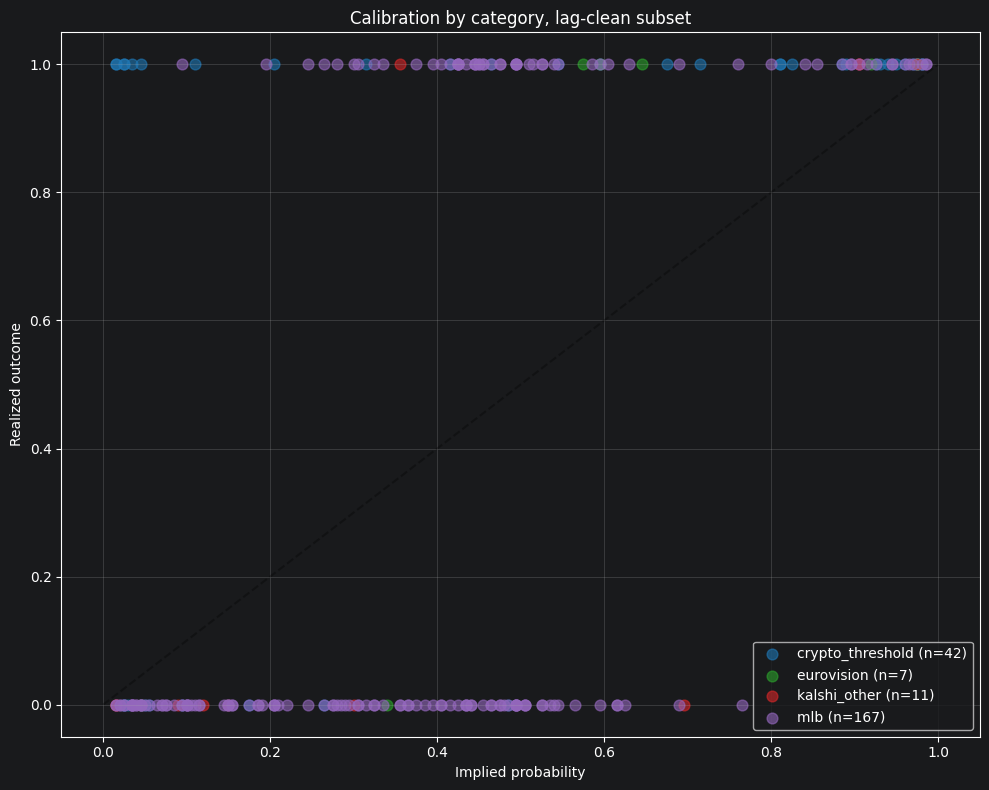

In [29]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))
categories = sorted(calibration_clean["category"].dropna().unique())
colors = plt.cm.tab10(range(len(categories)))
for category, color in zip(categories, colors, strict=True):
    subset = calibration_clean[calibration_clean["category"] == category]
    if len(subset) < 3:
        continue
    ax.scatter(
        subset["implied_prob"],
        subset["resolved_value"],
        c=[color],
        label=f"{category} (n={len(subset)})",
        alpha=0.6,
        s=60,
    )
ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
ax.set_xlabel("Implied probability")
ax.set_ylabel("Realized outcome")
ax.set_title("Calibration by category, lag-clean subset")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/tmp/calibration_by_category.png", dpi=120)
print("Saved /tmp/calibration_by_category.png")


### Section 8 findings

_Fill this in after running the category-segmented calibration cells._

- Categories with `n >= 5`: __
- Largest category: __
- Eurovision sample size: __
- Category-specific calibration pattern: __
- Next research question: __


## Section 9: Temporal price dynamics before resolution

Entries 19-21 tested final captured price, category segmentation, and static depth imbalance. This section tests whether the trajectory of prices in the two hours before final-book capture adds signal beyond the final mid-price level.


In [30]:
import os
from pathlib import Path

import statsmodels.api as sm
from scipy.stats import chi2

resolved_dir = Path(
    os.environ.get(
        "PM_EDGE_LOCAL_RESOLVED_DIR",
        str(Path(os.environ["PM_EDGE_LOCAL_FORWARD_INDEX_DIR"]).parent / "resolved_market_outcomes"),
    )
)
resolved_glob = str(resolved_dir / "**" / "*.parquet")

resolved_temporal = con.sql(f"""
    SELECT
        venue,
        market_id,
        resolved_value,
        venue_resolved_at_utc,
        final_top_bid,
        final_top_ask,
        final_snapshot_timestamp_utc AS final_book_ts,
        EXTRACT(EPOCH FROM (venue_resolved_at_utc - final_snapshot_timestamp_utc)) / 60 AS lag_minutes
    FROM read_parquet('{resolved_glob}', union_by_name=true)
    WHERE final_top_bid IS NOT NULL
      AND final_top_ask IS NOT NULL
      AND resolved_value IN (0.0, 1.0)
      AND venue_resolved_at_utc IS NOT NULL
      AND final_snapshot_timestamp_utc IS NOT NULL
""").df()
resolved_temporal = resolved_temporal[
    (resolved_temporal["lag_minutes"] > 0)
    & (resolved_temporal["lag_minutes"] < 240)
].copy()
print(f"Lag-clean resolved markets: {len(resolved_temporal)}")

temporal_rows = []
for _, row in resolved_temporal.iterrows():
    final_ts = pd.Timestamp(row["final_book_ts"])
    window_start = final_ts - pd.Timedelta(minutes=120)
    snapshots = con.execute(
        """
        SELECT timestamp_utc, mid
        FROM order_book_snapshots
        WHERE venue = ? AND market_id = ?
          AND timestamp_utc BETWEEN ? AND ?
          AND mid IS NOT NULL
        ORDER BY timestamp_utc
        """,
        [row["venue"], row["market_id"], window_start, final_ts],
    ).df()
    if len(snapshots) < 5:
        continue

    def closest_mid(
        target_ts: pd.Timestamp, snapshots=snapshots
    ) -> float | None:
        deltas = (snapshots["timestamp_utc"] - target_ts).abs()
        nearest_idx = deltas.idxmin()
        nearest_delta = abs(
            (snapshots.loc[nearest_idx, "timestamp_utc"] - target_ts).total_seconds()
        )
        if nearest_delta > 300:
            return None
        return float(snapshots.loc[nearest_idx, "mid"])

    mid_final = closest_mid(final_ts)
    mid_30 = closest_mid(final_ts - pd.Timedelta(minutes=30))
    mid_60 = closest_mid(final_ts - pd.Timedelta(minutes=60))
    mid_120 = closest_mid(final_ts - pd.Timedelta(minutes=120))
    mid_window = snapshots[
        (snapshots["timestamp_utc"] >= final_ts - pd.Timedelta(minutes=120))
        & (snapshots["timestamp_utc"] <= final_ts - pd.Timedelta(minutes=30))
    ]
    volatility = mid_window["mid"].std() if len(mid_window) > 2 else None
    temporal_rows.append(
        {
            "venue": row["venue"],
            "market_id": row["market_id"],
            "resolved_value": row["resolved_value"],
            "mid_final": mid_final,
            "mid_30": mid_30,
            "mid_60": mid_60,
            "mid_120": mid_120,
            "velocity_30min": (mid_final - mid_30) / 30
            if mid_final is not None and mid_30 is not None
            else None,
            "velocity_60min": (mid_30 - mid_60) / 30
            if mid_30 is not None and mid_60 is not None
            else None,
            "velocity_120min": (mid_60 - mid_120) / 60
            if mid_60 is not None and mid_120 is not None
            else None,
            "volatility": volatility,
            "snapshot_count": len(snapshots),
        }
    )

temporal_features = pd.DataFrame(temporal_rows)
print(f"Markets with >=5 snapshots in 120m window: {len(temporal_features)}")
print(
    f"Markets with full temporal features: "
    f"{temporal_features.dropna().shape[0] if not temporal_features.empty else 0}"
)
temporal_features.describe()


Lag-clean resolved markets: 230
Markets with >=5 snapshots in 120m window: 230
Markets with full temporal features: 120


,resolved_value,mid_final,mid_30,mid_60,mid_120,velocity_30min,velocity_60min,velocity_120min,volatility,snapshot_count
count,230.000000,230.000000,211.000000,191.000000,135.000000,211.00000,184.000000,126.000000,2.210000e+02,230.000000
mean,0.443478,0.415598,0.415254,0.418191,0.427596,-0.00025,0.000120,-0.000242,8.803888e-03,363.773913
std,0.497879,0.297889,0.287454,0.277325,0.277456,0.00359,0.001261,0.001955,3.689355e-02,124.191292
min,0.000000,0.002500,0.003500,0.004500,0.015000,-0.02250,-0.002667,-0.012083,0.000000e+00,21.000000
25%,0.000000,0.150000,0.165000,0.180000,0.205000,0.00000,0.000000,0.000000,6.948605e-18,274.000000
50%,0.000000,0.415000,0.425000,0.425000,0.425000,0.00000,0.000000,0.000000,5.563275e-17,390.500000
75%,1.000000,0.572500,0.575000,0.570000,0.565000,0.00000,0.000000,0.000000,2.224796e-16,469.000000
max,1.000000,0.985000,0.985000,0.980000,0.980000,0.01750,0.011000,0.006333,3.193566e-01,478.000000


In [ ]:
temporal_fit = temporal_features.dropna(
    subset=[
        "resolved_value",
        "mid_final",
        "velocity_30min",
        "velocity_60min",
        "velocity_120min",
        "volatility",
    ]
).copy()
print(f"Fitting on n={len(temporal_fit)}")

if len(temporal_fit) >= 10:
    y = temporal_fit["resolved_value"]
    baseline = sm.Logit(y, sm.add_constant(temporal_fit[["mid_final"]])).fit(disp=False)
    print(
        f"Model 1 (mid_final only): pseudo R² = {baseline.prsquared:.4f}, "
        f"AIC = {baseline.aic:.2f}"
    )
    for feature in ["velocity_60min", "velocity_120min", "volatility"]:
        model = sm.Logit(
            y,
            sm.add_constant(temporal_fit[["mid_final", feature]]),
        ).fit(disp=False)
        lr_stat = 2 * (model.llf - baseline.llf)
        print(f"\nModel (+ {feature}): pseudo R² = {model.prsquared:.4f}, AIC = {model.aic:.2f}")
        print(model.summary().tables[1])
        print(f"  LRT: chi2 = {lr_stat:.4f}, p = {chi2.sf(lr_stat, 1):.4f}")
else:
    print("Insufficient full-feature rows for logistic regression.")


### Section 9 findings

_Fill this in after running the temporal dynamics cells._

- Lag-clean resolved markets: __
- Markets with full 120-minute features: __
- Velocity result: __
- Volatility result: __
- Interpretation: __


## Findings

_Fill this in after running the notebook._

### Eurovision watch notes

_Re-run Section 6 throughout the day on May 16 to observe how prediction-market top_bid and top_ask evolve as the Eurovision final approaches and resolves. Note: prices below 0.5 mean the market thinks the country is unlikely to make top 5/10; prices climbing toward 1.0 indicate growing confidence. Markets should converge to either 0 or 1 by resolution._